In [10]:
%load_ext autoreload
%autoreload 2

In [1]:
import sys
sys.path.append('./')
sys.path.append('/Users/ASUS/Documents/GitHub/retrospective_t2e_analysis/auton-survival/')

import pandas as pd
import numpy as np

In [16]:
trials = ['oat', 'aimhigh', 'peace', 'sprint', 'accord', 'bari_2d']
outcome = ['comb', 'Primary', 'PRIMARY', 'PRIMARY','','']
location = ['datasets/OAT/Ancillary/', 'datasets/AIMHIGH/', 'datasets/PEACE/Data/', 'datasets/SPRINT_POP/Datasets/', 
            'datasets/ACCORD/', 'datasets/']
for trial in trials:
    from datasets_retrospective import load_+trial+_dataset
    outcomes+trial, features+trial, intervention+trial = load_+trial+dataset(location=location for location in location, outcome=outcome for outcome in outcome)

SyntaxError: invalid syntax (4117745685.py, line 6)

In [2]:
from datasets_retrospective import load_sprint_trial_data, load_aimhigh_trial_data, load_oat_trial_data, load_peace_trial_data, load_bari_2d_dataset, load_accord_dataset
outcomes, features, intervention, cat_feats, num_feats = load_sprint_trial_data(location='datasets/SPRINT_POP/Datasets/', outcome='PRIMARY')
# outcomes, features, intervention, cat_feats, num_feats = load_aimhigh_trial_data(location='datasets/AIMHIGH/', outcome='Primary')
# outcomes, features, intervention, cat_feats, num_feats = load_oat_trial_data(location='datasets/OAT/Ancillary/', outcome='comb')
# outcomes, features, intervention, cat_feats, num_feats = load_peace_trial_data(location='datasets/PEACE/Data/', outcome='PRIMARY')
# outcomes, features, intervention, cat_feats, num_feats = load_bari_2d_dataset(location='datasets/BARI2D/data/')
# outcomes, features, intervention, cat_feats, num_feats = load_accord_dataset(location='datasets/ACCORD/')

c:\Users\ASUS\Documents\GitHub\retrospective_t2e_analysis\auton-survival\auton_survival\datasets_retrospective.py:953: SyntaxWarning: "is" with a literal. Did you mean "=="?
  if outcome is 'PRIMARY': outcomedt = 'PRIMRYDT'


(9361, 27)


c:\Users\ASUS\Documents\GitHub\retrospective_t2e_analysis\auton-survival\auton_survival\datasets_retrospective.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.loc[:, col] = df[col].values.astype(str)
c:\Users\ASUS\Documents\GitHub\retrospective_t2e_analysis\auton-survival\auton_survival\datasets_retrospective.py:117: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  intervention[intervention == 1.0] = 'SBP target <120mm Hg'
c:\Users\ASUS\Documents\GitHub\retrospective_t2e_analysis\auton-survival\auton_survival\datasets_retrospective.py:117: SettingWithCopyWar

In [17]:
from sklearn.model_selection import train_test_split

# Split the SPRINT data into training, validation, and test data
x_tr, x_te, y_tr, y_te = train_test_split(features, outcomes, test_size=0.3, random_state=1, 
                                          stratify = outcomes.event + 2*(intervention=='SBP target <120mm Hg'))

print(f'Number of training data points: {len(x_tr)}')
print(f'Number of test data points: {len(x_te)}')

Number of training data points: 6552
Number of test data points: 2809


In [18]:
from auton_survival.preprocessing import Preprocessor

# Fit the imputer and scaler to the training data and transform the training, validation and test data
preprocessor = Preprocessor(cat_feat_strat='ignore', num_feat_strat= 'mean') 
transformer = preprocessor.fit(features, cat_feats=cat_feats, num_feats=num_feats,
                                one_hot=True, fill_value=-1)
x_tr = transformer.transform(x_tr)
x_te = transformer.transform(x_te)

In [5]:
from auton_survival.estimators import SurvivalModel
from auton_survival.metrics import survival_regression_metric
from sklearn.model_selection import ParameterGrid

# Define parameters for tuning the model
param_grid = {'bs' : [256],
              'learning_rate' : [ 1e-3]
             }

params = ParameterGrid(param_grid)

# Define the times for tuning the model hyperparameters and for evaluating the model
times = [1.0*365.25, 2.0*365.25, 3.0*365.25, 4.0*365.25]

# Perform hyperparameter tuning 
models = []
for param in params:
    model = SurvivalModel('dcph', layers=[], random_seed=0, bs=param['bs'], learning_rate=param['learning_rate'], epochs=100)
    
    # The fit method is called to train the model
    model.fit(x_tr, y_tr)
    

 55%|█████▌    | 55/100 [00:04<00:03, 12.72it/s]


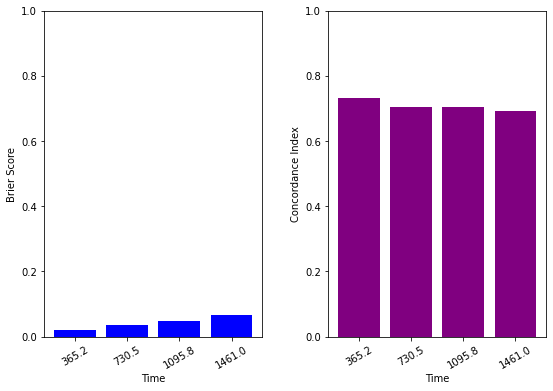

In [8]:
from examples.estimators_demo_utils import plot_performance_metrics
import matplotlib.pyplot as plt
plt.figure(figsize=(9,6))
# Obtain survival probabilities for test set
predictions_te = model.predict_survival(x_te, times)

# Compute the Brier Score and time-dependent concordance index for the test set to assess model performance
results = dict()
results['Brier Score'] = survival_regression_metric('brs', outcomes=y_te, predictions=predictions_te, 
                                                    times=times, outcomes_train=y_tr)
results['Concordance Index'] = survival_regression_metric('ctd', outcomes=y_te, predictions=predictions_te, 
                                                    times=times, outcomes_train=y_tr)
plot_performance_metrics(results, times)

In [9]:
results

{'Brier Score': array([0.02093225, 0.03516844, 0.04845033, 0.06587918]),
 'Concordance Index': [0.7313658524304486,
  0.7053369269044166,
  0.7049591634082859,
  0.6933604520204782]}